## imports

In [1]:
import mne
import os
import sys
import matplotlib.pyplot as plt
from sys import getsizeof
import pandas as pd

In [4]:
dir_base = "../../"
print(os.path.abspath(dir_base))

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [5]:
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "experiments_xeegnet")))
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main")))
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "models")))

In [6]:
%load_ext autoreload
%autoreload 2
from data_loading_expirements.load_data_pythonfun import *
from data_utils.load_data import *
from data_utils.perpare_data import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Path settings

In [7]:
def get_patient_id(patient_id_int):
    return f"{patient_id_int:03d}"

In [8]:
patient_id_int = 1

patient_id = get_patient_id(patient_id_int)
print(patient_id)

patient_id = "001"
patient_id_long = f"sub-{patient_id}"

001


In [11]:
# dir_base = "backend\\experiments_xeegnet"
dir_base = "..\\..\\"
dir_data = os.path.join(dir_base, "data\\datasets\\ds004504")
dir_data_abs = os.path.abspath(dir_data)

data_path = os.path.join(dir_data_abs, "sub-001\\eeg\\sub-001_task-eyesclosed_eeg.set")
data_path = os.path.join(dir_data, "sub-001\\eeg\\sub-001_task-eyesclosed_eeg.set")

## Read Data

In [12]:
eeg_data = mne.io.read_raw_eeglab(data_path, preload=True)

In [13]:
# eeg_data.plot()
# plt.show()

### single channel

In [14]:
eeg_channel, time_vector = load_eeg_data(participant=1, channel_name="Fp1", dir_data=dir_data)  # , n_points=10000

load_eeg_data called with: 1 Fp1 derivatives None
Loading data from: ..\..\data\datasets\ds004504\derivatives\sub-001\eeg\sub-001_task-eyesclosed_eeg.set


In [15]:
print(getsizeof(time_vector))
print(time_vector.nbytes / 1024 / 1024, "MB")

112
2.288055419921875 MB


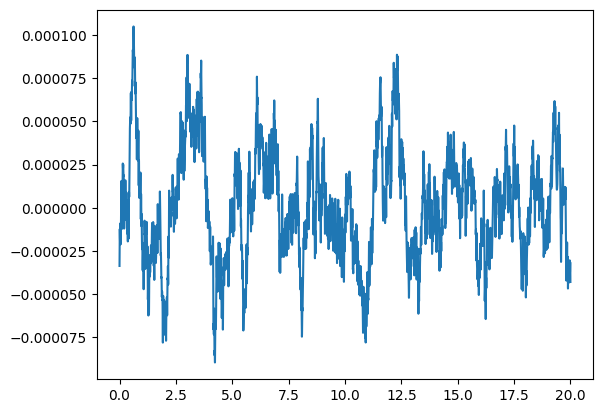

In [16]:
n = int(1e4)
plt.plot(time_vector[:n], eeg_channel[:n])
plt.show()

### Dataframe

In [17]:
df_eeg = eeg_data.to_data_frame()
df_eeg.head(3)

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,0.000,-189.892563,-141.845688,-107.373039,28.466799,-108.447258,-36.474609,-73.583984,173.486328,149.462891,156.201172,-19.873045,-112.158195,-59.130859,-12.158201,-78.271477,-131.396469,-103.271477,-18.212889,-126.708977
1,0.002,-180.419907,-137.353500,-100.048820,32.275391,-103.369133,-33.642578,-69.384766,177.099609,150.146484,161.279297,-4.345701,-108.544914,-54.736328,-9.423826,-75.537102,-128.173813,-98.681633,-14.404295,-122.900383
2,0.004,-166.992172,-135.058578,-105.761711,35.351562,-101.953117,-29.882812,-67.968742,180.078125,144.238281,160.546875,4.199220,-103.710930,-53.320312,-5.273437,-85.546867,-124.609367,-98.535149,-11.523437,-120.410149


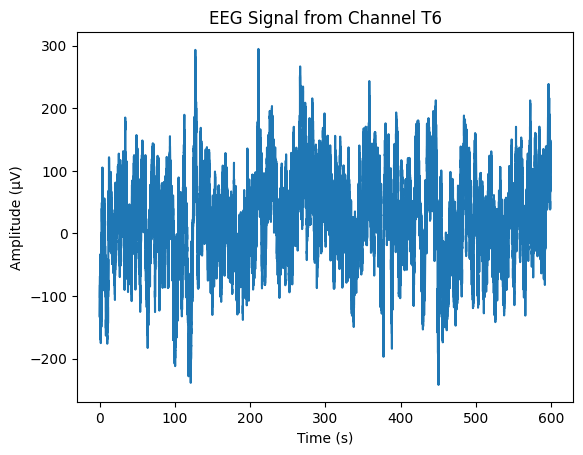

In [18]:
fig, ax = plt.subplots()
ax.plot(df_eeg["time"], df_eeg["T6"])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("EEG Signal from Channel T6")
plt.show()

In [19]:
disease_mapping = {"A": "Alzheimer Disease Group", "F": "Frontotemporal Dementia Group", "C": "Healthy Group"}

disease_encoding = {
    "A": 1,
    "F": 2,
    "C": 0,
}

metadata_path = os.path.join(dir_data, "participants.tsv")
df_metadata = pd.read_csv(metadata_path, sep="\t")
df_metadata["group_long"] = df_metadata["Group"].map(disease_mapping)
df_metadata["group_encoded"] = df_metadata["Group"].map(disease_encoding)
df_metadata.head()

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded
0,sub-001,F,57,A,16,Alzheimer Disease Group,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1
2,sub-003,M,70,A,14,Alzheimer Disease Group,1
3,sub-004,F,67,A,20,Alzheimer Disease Group,1
4,sub-005,M,70,A,22,Alzheimer Disease Group,1


# Load and cocnat data

In [22]:
participant_ids = [1, 2, 3]


def gen_filename(participant_id):
    return f"sub-{participant_id}/eeg/sub-{participant_id}_task-eyesclosed_eeg.set"


df_eeg = load_multiple_eegfiles(
    dir_data=dir_data,
    participant_ids=participant_ids,  # , 43
    gen_path_func=gen_filename,
    df_metadata=df_metadata,
    # n_max = 10000
)

Total memory usage of combined df_eeg: 71.33 MB


In [23]:
df_eeg

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,...,F8,T3,T4,T5,T6,Fz,Cz,Pz,participant_id,diagnosis
0,0.000000,-189.892563,-141.845688,-107.373039,28.466799,-108.447258,-36.474609,-73.583984,173.486328,149.462891,...,-112.158195,-59.130859,-12.158201,-78.271477,-131.396469,-103.271477,-18.212889,-126.708977,sub-001,1
1,0.002000,-180.419907,-137.353500,-100.048820,32.275391,-103.369133,-33.642578,-69.384766,177.099609,150.146484,...,-108.544914,-54.736328,-9.423826,-75.537102,-128.173813,-98.681633,-14.404295,-122.900383,sub-001,1
2,0.004000,-166.992172,-135.058578,-105.761711,35.351562,-101.953117,-29.882812,-67.968742,180.078125,144.238281,...,-103.710930,-53.320312,-5.273437,-85.546867,-124.609367,-98.535149,-11.523437,-120.410149,sub-001,1
3,0.006000,-160.205063,-132.958969,-105.322258,38.037109,-99.755852,-27.099607,-65.869133,183.349609,144.482422,...,-99.365227,-50.927734,-2.392576,-84.912102,-121.044914,-95.556633,-9.326170,-118.212883,sub-001,1
4,0.008000,-159.326157,-124.462883,-104.150383,41.162109,-98.486320,-24.462891,-64.794914,184.619141,146.044922,...,-96.337883,-48.095699,-2.587890,-82.470695,-120.068352,-91.748039,-7.666015,-116.357414,sub-001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849995,307.089996,56.152340,30.468746,-87.402344,10.546874,-28.222656,43.554684,120.214836,95.507805,11.230468,...,151.269531,-97.363281,104.003899,-113.281250,176.953125,63.476559,0.878905,-4.589844,sub-003,1
849996,307.092010,58.886715,38.183594,-84.277344,16.503906,-24.902344,48.046871,124.414055,97.558586,12.597656,...,158.203125,-91.210938,109.863274,-111.914062,180.078125,69.433586,5.566407,-2.148436,sub-003,1
849997,307.093994,65.673820,44.775387,-78.662109,22.900389,-20.361326,54.541012,129.150391,101.513664,13.330076,...,164.697266,-87.158203,116.650383,-111.279297,184.716797,78.857414,12.646482,2.392576,sub-003,1
849998,307.096008,75.048820,54.150387,-72.314453,30.322264,-14.599607,66.259758,134.716797,111.669914,21.630857,...,174.365234,-81.689453,124.267570,-105.908203,190.576172,89.111320,20.947264,8.447264,sub-003,1
